# Confidence-Coloured Text – Full Test

Each word in the corrected transcription is rendered in a grey shade  
determined by its per-word **WER confidence** from the TrOCR model:

| Confidence | Meaning | Colour |
|---|---|---|
| 1.0 | model certain | **black** |
| 0.5 | uncertain | grey |
| 0.0 | very uncertain | white (invisible) |

**Source of confidence scores:** geometric mean of per-token log-probabilities  
stored in `data/confidence/<page_id>.txt` (computed by TrOCR with `output_scores=True`).

**Word alignment:** `difflib.SequenceMatcher` maps corrected-transcription words  
to their original confidence scores. Qwen-substituted words inherit the  
confidence of the original low-confidence word they replaced.

**Output:** `data/confidence_coloured_text.html` — viewable in any browser.

In [1]:
import difflib
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

CONF_DIR      = REPO_ROOT / 'data' / 'confidence'
CORRECTED_DIR = REPO_ROOT / 'data' / 'corrected_transcriptions'
OUTPUT_HTML   = REPO_ROOT / 'data' / 'confidence_coloured_text.html'

# Default confidence for words inserted by Qwen with no original counterpart
DEFAULT_CONF = 0.5

def sort_key(p: Path):
    m = re.match(r'B(\d+)_P(\d+)', p.stem)
    return (int(m.group(1)), int(m.group(2))) if m else (99, 9999)

# Only process pages that have both a corrected transcription and a confidence file
corr_files = {p.stem: p for p in CORRECTED_DIR.glob('*.txt')}
conf_files = {p.stem: p for p in CONF_DIR.glob('*.txt')}
page_ids   = sorted(corr_files.keys() & conf_files.keys(), key=lambda s: sort_key(Path(s)))

print(f'Pages with both corrected text and confidence file: {len(page_ids)}')
print('First 5:', page_ids[:5])

Pages with both corrected text and confidence file: 36
First 5: ['B1_P012', 'B1_P014', 'B1_P015', 'B1_P016', 'B1_P017']


---
## Step 1 – Parse confidence files and corrected transcriptions

In [2]:
def parse_confidence_file(path: Path) -> list:
    """
    Parse a confidence file into a flat list of (word: str, conf: float).
    Handles both  word(0.98)  and  <<word>>(0.42)  formats.
    """
    result = []
    token_re = re.compile(
        r'<<([^>]+)>>\(([\d.]+)\)'   # <<word>>(conf)
        r'|'
        r'([^\s(]+)\(([\d.]+)\)'     # word(conf)
    )
    for line in path.read_text(encoding='utf-8').splitlines():
        if not re.match(r'\[L\d+\]', line):
            continue
        body = line.split('] ', 1)[1] if '] ' in line else line
        for m in token_re.finditer(body):
            if m.group(1):
                word, conf = m.group(1).strip(), float(m.group(2))
            else:
                word, conf = m.group(3).strip(), float(m.group(4))
            if word:
                result.append((word, max(0.0, min(1.0, conf))))
    return result


def parse_corrected_file(path: Path) -> list:
    """
    Parse a corrected transcription into a list of (line_index: int, word: str).
    Skips the === header line.
    """
    result = []
    for i, line in enumerate(path.read_text(encoding='utf-8').splitlines()):
        if line.startswith('==='):
            continue
        for word in line.split():
            result.append((i, word))
    return result


def _normalise(word: str) -> str:
    return re.sub(r'[^\w]', '', word.lower())


def align_words(conf_words: list, corr_words_with_line: list) -> list:
    """
    Align corrected words to original confidence scores via SequenceMatcher.
    Returns list of (line_index: int, word: str, confidence: float, qwen_replaced: bool).

    opcodes:
      equal   → grey, original confidence
      replace → GREEN, average confidence of replaced originals
      insert  → grey, DEFAULT_CONF
      delete  → skip
    """
    orig_keys = [_normalise(w) for w, _ in conf_words]
    corr_keys = [_normalise(w) for _, w in corr_words_with_line]

    matcher = difflib.SequenceMatcher(None, orig_keys, corr_keys, autojunk=False)
    result  = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            for i, j in zip(range(i1, i2), range(j1, j2)):
                li, word = corr_words_with_line[j]
                result.append((li, word, conf_words[i][1], False))

        elif tag == 'replace':
            orig_confs = [conf_words[i][1] for i in range(i1, i2)]
            avg_conf   = sum(orig_confs) / len(orig_confs) if orig_confs else DEFAULT_CONF
            for j in range(j1, j2):
                li, word = corr_words_with_line[j]
                result.append((li, word, avg_conf, True))   # <-- Qwen replacement

        elif tag == 'insert':
            for j in range(j1, j2):
                li, word = corr_words_with_line[j]
                result.append((li, word, DEFAULT_CONF, False))

        # 'delete': skip

    return result


print('Parse and alignment functions defined.')

Parse and alignment functions defined.


---
## Step 2 – HTML generation

Confidence → greyscale colour:
```
gray_value = int(255 × (1 − confidence))
color       = rgb(gray_value, gray_value, gray_value)
```
→ confidence 1.0 = `rgb(0,0,0)` = **black** (certain)  
→ confidence 0.0 = `rgb(255,255,255)` = **white** (invisible)

In [ ]:
QWEN_GREEN = '#1a8c1a'   # green for Qwen-corrected words

def conf_to_rgb(conf: float) -> str:
    g = int(255 * (1.0 - conf))
    return f'rgb({g},{g},{g})'


def make_page_html(page_id: str, aligned: list) -> str:
    """
    Build HTML fragment for one manuscript page.
    - Grey shade   → TrOCR confidence (certain=black, uncertain=white)
    - Green        → word was replaced by Qwen post-correction
    """
    m      = re.match(r'B(\d+)_P(\d+)', page_id)
    header = f'Book {m.group(1)}, Page {m.group(2)}' if m else page_id

    by_line: dict = {}
    for li, word, conf, is_replaced in aligned:
        by_line.setdefault(li, []).append((word, conf, is_replaced))

    line_divs = []
    for li in sorted(by_line):
        spans = ' '.join(
            (
                f'<span style="color:{QWEN_GREEN}" title="Qwen correction (orig conf={c:.2f})">{word}</span>'
                if replaced else
                f'<span style="color:{conf_to_rgb(c)}" title="conf={c:.2f}">{word}</span>'
            )
            for word, c, replaced in by_line[li]
        )
        line_divs.append(f'  <div class="line">{spans}</div>')

    return (
        f'<section class="page" id="{page_id}">\n'
        f'  <div class="page-id">{header}</div>\n'
        + '\n'.join(line_divs)
        + '\n</section>'
    )


HTML_HEAD = """\
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>Forster Journal – Confidence-Coloured Text</title>
  <style>
    body {
      background: #ffffff;
      font-family: Georgia, 'Times New Roman', serif;
      font-size: 13pt;
      line-height: 1.9;
      max-width: 860px;
      margin: 0 auto;
      padding: 40px 30px 80px;
    }
    h1 { font-size: 18pt; margin-bottom: 4px; }
    .subtitle { color: #555; font-size: 10pt; margin-bottom: 2em; }

    .legend {
      display: flex;
      align-items: center;
      gap: 16px;
      margin-bottom: 2.5em;
      font-size: 10pt;
      color: #333;
      flex-wrap: wrap;
    }
    .legend-bar {
      width: 180px;
      height: 14px;
      border: 1px solid #ccc;
      background: linear-gradient(to right, #000, #fff);
      border-radius: 3px;
      flex-shrink: 0;
    }
    .legend-green {
      display: inline-block;
      width: 14px;
      height: 14px;
      background: #1a8c1a;
      border-radius: 3px;
      vertical-align: middle;
      margin-right: 4px;
    }

    .page { margin-bottom: 2.5em; border-top: 1px solid #e0e0e0; padding-top: 1em; }
    .page-id {
      font-size: 9pt;
      color: #aaa;
      letter-spacing: .05em;
      margin-bottom: .4em;
    }
    .line { min-height: 1.4em; }
    span { cursor: default; }
    span:hover { background: #f0f0ff; }
  </style>
</head>
<body>
  <h1>Forster Journal – HMS Resolution (1772–1774)</h1>
  <p class="subtitle">
    Word colour encodes TrOCR per-word confidence (geometric mean of token log-probs).<br>
    Hover over any word to see its confidence score.
  </p>
  <div class="legend">
    <span>conf = 1.0 (certain)</span>
    <div class="legend-bar"></div>
    <span>conf = 0.0 (uncertain)</span>
    <span style="margin-left:12px">
      <span class="legend-green"></span> Qwen post-correction
    </span>
  </div>
"""

HTML_TAIL = "\n</body>\n</html>\n"

print('HTML generation functions defined.')

---
## Step 3 – Process all pages and write HTML

In [4]:
from tqdm import tqdm

page_sections = []
all_confs     = []

stats = {'pages': 0, 'words': 0, 'aligned': 0, 'qwen_replaced': 0, 'inserted': 0}

for page_id in tqdm(page_ids, desc='Building coloured HTML'):
    conf_words        = parse_confidence_file(conf_files[page_id])
    corr_words_w_line = parse_corrected_file(corr_files[page_id])

    if not conf_words or not corr_words_w_line:
        continue

    aligned = align_words(conf_words, corr_words_w_line)

    page_sections.append(make_page_html(page_id, aligned))
    all_confs.extend(c for _, _, c, _ in aligned)

    stats['pages']        += 1
    stats['words']        += len(corr_words_w_line)
    stats['qwen_replaced']+= sum(1 for _, _, _, r in aligned if r)
    stats['inserted']     += sum(1 for _, _, c, r in aligned if not r and c == DEFAULT_CONF)
    stats['aligned']      += sum(1 for _, _, c, r in aligned if not r and c != DEFAULT_CONF)

with open(OUTPUT_HTML, 'w', encoding='utf-8') as f:
    f.write(HTML_HEAD)
    f.write('\n\n'.join(page_sections))
    f.write(HTML_TAIL)

print(f'\nSaved: {OUTPUT_HTML}')
print(f"Pages processed  : {stats['pages']}")
print(f"Total words      : {stats['words']}")
print(f"Confidence-mapped: {stats['aligned']}")
print(f"Qwen-replaced    : {stats['qwen_replaced']}  (shown in green)")
print(f"Default (0.5)    : {stats['inserted']}  (Qwen-inserted / unmatched)")
if all_confs:
    import statistics
    print(f"Mean confidence  : {statistics.mean(all_confs):.3f}")
    print(f"Median confidence: {statistics.median(all_confs):.3f}")

Building coloured HTML: 100%|██████████| 36/36 [00:00<00:00, 889.39it/s]


Saved: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/confidence_coloured_text.html
Pages processed  : 36
Total words      : 6362
Confidence-mapped: 6269
Qwen-replaced    : 75  (shown in green)
Default (0.5)    : 18  (Qwen-inserted / unmatched)
Mean confidence  : 0.903
Median confidence: 1.000


In [5]:
# Inline preview of the first page section
from IPython.display import HTML

preview_html = HTML_HEAD + page_sections[0] + HTML_TAIL if page_sections else '<p>No pages processed.</p>'
HTML(preview_html)

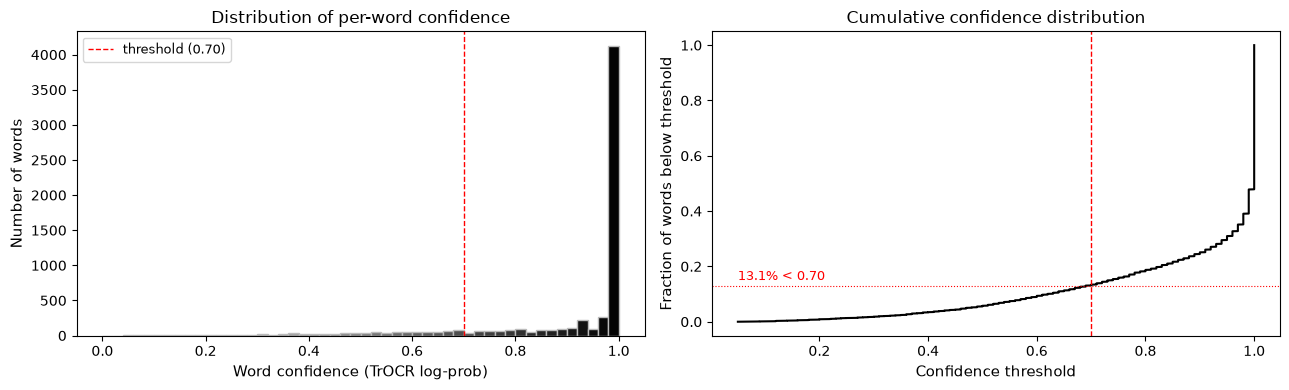

Histogram saved: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/confidence_distribution.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if not all_confs:
    print('No confidence values collected.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # --- Left: histogram ---
    ax = axes[0]
    bins  = np.linspace(0, 1, 51)
    n, _, patches = ax.hist(all_confs, bins=bins, edgecolor='none')
    # Colour each bar by the confidence value it represents
    bin_centres = 0.5 * (bins[:-1] + bins[1:])
    for patch, bc in zip(patches, bin_centres):
        g = 1.0 - bc          # 0 = black (high conf), 1 = white (low conf)
        patch.set_facecolor((g, g, g))
        patch.set_edgecolor('#bbbbbb')

    ax.set_xlabel('Word confidence (TrOCR log-prob)', fontsize=11)
    ax.set_ylabel('Number of words', fontsize=11)
    ax.set_title('Distribution of per-word confidence', fontsize=12)
    ax.axvline(0.70, color='red', linestyle='--', linewidth=1, label='threshold (0.70)')
    ax.legend(fontsize=9)

    # --- Right: cumulative ---
    ax2 = axes[1]
    sorted_c = np.sort(all_confs)
    ax2.plot(sorted_c, np.linspace(0, 1, len(sorted_c)), color='black', linewidth=1.5)
    ax2.axvline(0.70, color='red', linestyle='--', linewidth=1)
    frac_below = np.mean(np.array(all_confs) < 0.70)
    ax2.axhline(frac_below, color='red', linestyle=':', linewidth=0.8)
    ax2.set_xlabel('Confidence threshold', fontsize=11)
    ax2.set_ylabel('Fraction of words below threshold', fontsize=11)
    ax2.set_title('Cumulative confidence distribution', fontsize=12)
    ax2.text(0.05, frac_below + 0.02, f'{frac_below*100:.1f}% < 0.70',
             fontsize=9, color='red')

    plt.tight_layout()
    fig_path = REPO_ROOT / 'data' / 'confidence_distribution.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Histogram saved: {fig_path}')

---
## Output

| File | Description |
|---|---|
| `data/confidence_coloured_text.html` | Full document, hover for exact score |
| `data/confidence_distribution.png` | Histogram + CDF of confidence scores |

**Reading the coloured text:**
- **Black words** → TrOCR was highly confident → likely correctly transcribed
- **Grey words** → moderate uncertainty → review recommended
- **White / faint words** → very low confidence → likely OCR errors (Qwen attempted correction)